Date: 7/22

Literature Review:


1.   [Negative binomial count splitting for single-cell RNA sequencing data - arXiv](https://arxiv.org/pdf/2307.12985)
2.   [Copula modeling of gene coexpression in single-cell RNA sequencing data - bioRxiv](https://www.biorxiv.org/content/10.64898/2025.12.04.692380v1.full.pdf)


Key bugs and their solutions


1.   Adding gamma i instead of multiplying by \(exp\) gamma i --> could result in negative mu value; if gamma i is negative enough, it could make the mu value \(mean\) zero or negative overall, which would break NB parameterization \(p/n no longer valid\)

SOLUTION: added a floor to mu in step 8

2.   Because I added jitter factor to correlation, where not all correlation coefficients exactly equal rho, which could result in a matrix being invalid

SOLUTION: used eigenvalue checking \(one hidden eigenvalue per each correlation coefficient baked into the matrix that can be retrieved any time\) where the model checks that all eigenvalues are either zero or positive before finalizing the correlation matrix; if an eigenvalue is negative, it will rebuild the correlation matrix \(also in step 8\)



# Synthetic scRNA-seq Data Generator — Correlated Gene Modules

**What this notebook is:** generates synthetic single-cell RNA-seq count data with a known ground truth, where the 100 "signal" genes are split into 4 **correlated gene modules** (3 disease modules whose mean differs by group + 1 distractor module that is equally correlated but NOT group-differential — a negative control). Compare to `flat_syntheticdata.ipynb` (no modules at all) and `correlated_with_subtypes_syntheticdata.ipynb` (this design plus per-patient disease-subtype heterogeneity).

**Data-generating hierarchy:** patient → cell → gene, with an added module layer: genes within a module share a Gaussian-copula-induced correlation, on top of the same patient/cell/technical structure as the flat design. Everything is seeded (`seed = 42`) for reproducibility.

## Table of contents
- [Step 1: Imports and random seed](#Step-1)
- [Step 2: Simulation parameters](#Step-2) — **start here if you want to change anything about the data**
- [Step 3: Patient metadata](#Step-3)
- [Step 4: Cell metadata (size factors)](#Step-4)
- [Step 5: Gene labeling and module assignment](#Step-5)
- [Step 6: Patient random effects (`gamma_i`)](#Step-6)
- [Step 7: Group-specific means](#Step-7)
- [Step 8: Simulate gene expression counts](#Step-8) — the core generative step (Gaussian copula NB)
- [Step 9: Reshape to gene x cell matrix](#Step-9)
- [Step 10: Per-gene summary statistics](#Step-10)
- [Step 11: Box plot — signal vs. background](#Step-11)
- [Step 11b: Validate the induced module correlation](#Step-11b)
- [Step 11c: Dataset overview](#Step-11c)
- [Step 11d: Technical/patient-effect distributions (QC)](#Step-11d)
- [Step 11e: Expression distribution by gene type](#Step-11e)
- [Step 11f: Per-module expression by group](#Step-11f)
- [Step 11g: Correlation heatmaps](#Step-11g)
- [Step 11g-ii: Zoomed heatmap (module vs. background)](#Step-11g-ii)
- [Step 11h: PCA of cells using module genes](#Step-11h)

**This notebook ends at the fully-generated, validated dataset** (`counts_df`, `genes_df` with `module_id`, `patients_df`, `cells_df`). Baseline model testing (L1, STG, and others) is deliberately a separate concern — see the accompanying baseline-methods notebook, which is meant to `%run` this one first and then work from the in-memory data it leaves behind.

## Step 1: imports and random seed

Fixes reproducibility for everything that follows via the legacy global `np.random` state. A few later steps (the copula draws in Step 8) deliberately use a separate `np.random.default_rng(seed)` instead, so they don't shift the legacy stream's sequence and disturb draws elsewhere. **Run this notebook top-to-bottom once per session** — re-running an individual cell out of order re-consumes random draws and desynchronizes downstream results from what's shown here.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

seed = 42
np.random.seed(seed)

print("Imported numpy, pandas, scipy.stats, matplotlib, seaborn")
print("Random seed set to", seed)

Imported numpy, pandas, scipy.stats, matplotlib, seaborn
Random seed set to 42


## Step 2: simulation parameters

Every knob that controls the simulated data lives here, in one place. **Change values here, not inline further down the notebook.**

**Quick tuning guide:**
- `fold_change`, `dispersion`, `sigma2` — same meaning as the flat design: signal-strength, per-gene noise (lower = noisier), and patient-effect variance (higher = noisier). Currently matched to `flat_syntheticdata.ipynb` and `correlated_with_subtypes_syntheticdata.ipynb` on purpose, so comparisons across the three notebooks aren't confounded by different task difficulty.
- `n_modules` / `n_distractor_modules` — how the 100 signal genes are split into equal-size modules; all but the last `n_distractor_modules` are disease modules (mean differs by group), the rest are distractors (correlated, but NOT group-differential — a negative control).
- `within_module_correlation` — target Pearson correlation between genes in the same module (0.6 by default).
- `correlation_noise` — 0.0 gives every gene pair in a module *exactly* `within_module_correlation` (a perfectly uniform heatmap block); raising it (try 0.05-0.15 for "a bit noisy", 0.2-0.3 for "quite noisy") jitters each pair around that target for a messier, more realistic-looking block, at the cost of pulling the realized average correlation down a bit once the matrix is repaired back to a valid correlation matrix (see `build_module_corr_matrix` in Step 8).

**Debugging tip:** if Step 8 errors on `np.linalg.cholesky`, it means `build_module_corr_matrix` produced a matrix that isn't positive-definite — most likely `correlation_noise` was pushed high enough that the single-pass eigenvalue-clip repair wasn't enough. Try lowering `correlation_noise` first.

In [ ]:
# Step 2: harder simulation parameters
#
n_patients_group1 = 10
n_patients_group2 = 10
cells_per_patient = 50
n_genes_total = 1000
n_signal_genes = 100

fold_change = 3
mu_background = 2
sigma2 = 0.20
dispersion = 15.0

size_factor_mean = 2000
size_factor_sd = 300

n_modules = 4
n_distractor_modules = 1
genes_per_module = n_signal_genes // n_modules
within_module_correlation = 0.6  # target Pearson rho between genes in the same module

#  0.05-0.15 for "a bit noisy", 0.2-0.3 for "quite noisy".
# 0.0 reproduces the original perfect-block behavior exactly.
correlation_noise = 0.0

print("Simulation parameters defined")
print("Group 1 patients:", n_patients_group1)
print("Group 2 patients:", n_patients_group2)
print("Cells per patient:", cells_per_patient)
print("Total genes:", n_genes_total)
print("Signal genes:", n_signal_genes)
print("Fold change:", fold_change)
print("Modules:", n_modules, "x", genes_per_module, "genes (", n_distractor_modules, "distractor )")
print("Within-module target correlation:", within_module_correlation)
print("Correlation noise:", correlation_noise)

Simulation parameters defined
Group 1 patients: 10
Group 2 patients: 10
Cells per patient: 50
Total genes: 1000
Signal genes: 100
Fold change: 3
Modules: 4 x 25 genes ( 1 distractor )
Within-module target correlation: 0.6
Correlation noise: 0.0


## Step 3: patient-level metadata

Assigns each of the 20 patients to Group1 (diseased, `n_patients_group1`) or Group2 (healthy, `n_patients_group2`).

In [ ]:
# Step 3: create patient metadata

patient_ids = [f"P{i+1}" for i in range(n_patients_group1 + n_patients_group2)]
groups = (
    ["Group1"] * n_patients_group1 +
    ["Group2"] * n_patients_group2
)

patients_df = pd.DataFrame({
    "patient_id": patient_ids,
    "group": groups
})

patients_df

,patient_id,group
0,P1,Group1
1,P2,Group1
2,P3,Group1
3,P4,Group1
4,P5,Group1
5,P6,Group1
6,P7,Group1
7,P8,Group1
8,P9,Group1
9,P10,Group1


## Step 4: cell-level metadata

Each patient contributes `cells_per_patient` cells, and each cell gets its own `size_factor` — a technical sequencing-depth effect, not biology. This is the quantity that needs to be normalized out (Step 11b onward) before measuring "real" gene-gene correlation.

In [ ]:
# Step 4: create cell metadata with size factors

cell_rows = []

for _, row in patients_df.iterrows():
    patient_id = row["patient_id"]
    group = row["group"]

    size_factors = np.random.normal(loc=size_factor_mean, scale=size_factor_sd, size=cells_per_patient)
    size_factors = np.clip(size_factors, a_min=1, a_max=None)

    for cell_idx in range(cells_per_patient):
        cell_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": f"{patient_id}_C{cell_idx+1}",
            "size_factor": size_factors[cell_idx]
        })

cells_df = pd.DataFrame(cell_rows)

cells_df.head()

,patient_id,group,cell_id,size_factor
0,P1,Group1,P1_C1,2149.014246
1,P1,Group1,P1_C2,1958.520710
2,P1,Group1,P1_C3,2194.306561
3,P1,Group1,P1_C4,2456.908957
4,P1,Group1,P1_C5,1929.753988


## Step 5: gene labeling and module assignment

Splits the 100 signal genes into `n_modules` equal-size groups (`module_id` column): all but the last `n_distractor_modules` are "disease modules" (`disease_modules`), the rest are "distractor modules" (`distractor_module_names`) — correlated with each other just as strongly, but their mean does NOT differ by group. The 900 background genes get `module_id = "none"`.

In [ ]:
# Step 5: label genes and assign correlated gene modules

gene_ids = [f"G{i+1}" for i in range(n_genes_total)]

signal_gene_ids = gene_ids[:n_signal_genes]
background_gene_ids = gene_ids[n_signal_genes:]

module_names = [f"M{i+1}" for i in range(n_modules)]
disease_modules = module_names[: n_modules - n_distractor_modules]
distractor_module_names = module_names[n_modules - n_distractor_modules :]

gene_module = {}
for m_idx, module in enumerate(module_names):
    start = m_idx * genes_per_module
    end = start + genes_per_module
    for gene_id in signal_gene_ids[start:end]:
        gene_module[gene_id] = module

genes_df = pd.DataFrame({
    "gene_id": gene_ids,
    "gene_type": ["signal"] * n_signal_genes + ["background"] * (n_genes_total - n_signal_genes)
})
genes_df["module_id"] = genes_df["gene_id"].map(gene_module).fillna("none")
genes_df["is_disease_module"] = genes_df["module_id"].isin(disease_modules)

print("Disease modules (mean differs by group):", disease_modules)
print("Distractor modules (correlated, but NOT group-differential):", distractor_module_names)
genes_df.head(10)

Disease modules (mean differs by group): ['M1', 'M2', 'M3']
Distractor modules (correlated, but NOT group-differential): ['M4']


,gene_id,gene_type,module_id,is_disease_module
0,G1,signal,M1,True
1,G2,signal,M1,True
2,G3,signal,M1,True
3,G4,signal,M1,True
4,G5,signal,M1,True
5,G6,signal,M1,True
6,G7,signal,M1,True
7,G8,signal,M1,True
8,G9,signal,M1,True
9,G10,signal,M1,True


## Step 6: patient random effects (`gamma_i`)

A per-patient intercept representing a genuine patient-level effect (e.g. overall transcriptional activity or technical batch). Step 8 applies it additively to disease-module, distractor-module, and background genes alike — since a real patient-level effect should shift all of that patient's expression together, not just the disease-relevant genes. See Step 11b's note for why this matters for correlation measurements.

In [ ]:
# Step 6: patient random effects

patient_effects = np.random.normal(
    loc=0,
    scale=np.sqrt(sigma2),
    size=len(patients_df)
)

patients_df["gamma_i"] = patient_effects

patients_df

,patient_id,group,gamma_i
0,P1,Group1,0.625811
1,P2,Group1,0.413509
2,P3,Group1,0.026668
3,P4,Group1,-0.289319
4,P5,Group1,0.312255
5,P6,Group1,0.175972
6,P7,Group1,0.400343
7,P8,Group1,0.284057
8,P9,Group1,0.469374
9,P10,Group1,-0.239364


## Step 7: group-specific means

Defines the "boosted" mean used for disease-module genes in Group1 (`mu_group1_signal`, `fold_change` applied) vs. the baseline mean used everywhere else (`mu_background`) — for Group2, for the distractor module in both groups, and for background genes.

In [ ]:
# Step 7: define group-specific means
#
# Disease-module genes: mean shifts with group (fold_change applied in Group1)
# Distractor-module genes: same mean in both groups (correlated, not diagnostic)
# Background genes: unchanged, independent, same mean in both groups

mu_group1_signal = mu_background * fold_change
mu_group2_signal = mu_background

mu_group1_background = mu_background
mu_group2_background = mu_background

print("mu_group1_signal (disease modules, Group1) =", mu_group1_signal)
print("mu_group2_signal (disease modules, Group2) =", mu_group2_signal)
print("mu_group1_background (distractor module + background, Group1) =", mu_group1_background)
print("mu_group2_background (distractor module + background, Group2) =", mu_group2_background)

mu_group1_signal (disease modules, Group1) = 6
mu_group2_signal (disease modules, Group2) = 2
mu_group1_background (distractor module + background, Group1) = 2
mu_group2_background (distractor module + background, Group2) = 2


## Step 8: simulate gene expression counts — the core generative step (Gaussian copula NB)

Genes within the same module are sampled with a **Gaussian copula**: draw a vector of correlated standard-normal latents per (module, cell) using `build_module_corr_matrix` (rho on the off-diagonals, optionally jittered by `correlation_noise`), map each latent to a uniform via the standard normal CDF, then invert each gene's own Negative Binomial CDF at that uniform (`nbinom.ppf`). This keeps every gene's marginal NB distribution exactly as parameterized (same mean/dispersion as the flat design) while inducing real pairwise correlation among genes in the same module. Background genes are sampled independently, exactly as in the flat design.

`gamma_i` is applied additively to every gene's mean — disease-module, distractor-module, and background alike — and floored at `MU_FLOOR` in case an extreme `gamma_i` draw would otherwise push a mean to zero or below.

**Debugging tips:**
- `ValueError` from `nbinom.rvs`/`nbinom.ppf` almost always means an invalid `p` (must be in `(0,1)`), tracing back to `mu <= 0` — see Step 6's note.
- `np.linalg.cholesky` failing means `build_module_corr_matrix` produced a non-positive-definite matrix — see Step 2's note about `correlation_noise`.
- This is the slowest cell in the notebook (one loop iteration per cell, one copula draw per module, one NB draw per background gene). If you're only iterating on a baseline model and haven't touched Step 2's data parameters, you don't need to re-run this cell again this session.

In [ ]:
# Step 8: simulate gene expression counts (module-aware Gaussian copula NB sampling)
#
# Genes within the same module are sampled with a Gaussian copula: draw a
# vector of correlated standard-normal latents per (module, cell) using a
# module correlation matrix (see build_module_corr_matrix below - rho on
# the off-diagonals, optionally jittered by correlation_noise), map each
# latent to a uniform via the standard normal CDF, then invert each gene's
# own NB CDF at that uniform (nbinom.ppf). This keeps every gene's marginal
# NB distribution exactly as parameterized (same mean/dispersion as before)
# while inducing real pairwise correlation among genes in the same module.
# Background genes are sampled independently, unchanged.
#
# A separate Generator is used for the copula draws so the existing global
# np.random stream (patients_df, cells_df, background genes) is undisturbed.

from scipy.stats import nbinom, norm

rng = np.random.default_rng(seed)

def build_module_corr_matrix(size, rho, noise, rng):
    """Compound-symmetric correlation matrix (rho off-diagonal). If noise > 0,
    jitter each pair's correlation with Gaussian noise, then repair the
    result back into a valid correlation matrix (clip negative eigenvalues,
    rescale to a unit diagonal) -- this is what makes the module's heatmap
    block look "noisy"/imperfect instead of a flat, uniform rho everywhere.
    noise=0 reproduces the exact uniform-rho matrix used previously."""
    corr = np.eye(size) * (1 - rho) + rho
    if noise > 0:
        jitter = rng.normal(loc=0.0, scale=noise, size=(size, size))
        jitter = (jitter + jitter.T) / 2
        np.fill_diagonal(jitter, 0.0)
        corr = corr + jitter
        eigvals, eigvecs = np.linalg.eigh(corr)
        eigvals = np.clip(eigvals, 1e-6, None)
        corr = eigvecs @ np.diag(eigvals) @ eigvecs.T
        d = np.sqrt(np.diag(corr))
        corr = corr / np.outer(d, d)
    corr += np.eye(size) * 1e-8  # numerical safety margin before Cholesky
    return corr

MU_FLOOR = 1e-6  # keeps mu strictly positive so the NB parameterization stays valid

# One correlation matrix / Cholesky factor covers every module (same size,
# same target rho + noise), so compute it once.
corr_matrix = build_module_corr_matrix(genes_per_module, within_module_correlation, correlation_noise, rng)
chol_factor = np.linalg.cholesky(corr_matrix)

module_gene_lists = {
    module: genes_df.loc[genes_df["module_id"] == module, "gene_id"].tolist()
    for module in module_names
}

count_rows = []

for _, cell in cells_df.iterrows():
    patient_id = cell["patient_id"]
    group = cell["group"]
    cell_id = cell["cell_id"]
    size_factor = cell["size_factor"]
    gamma_i = patients_df.loc[patients_df["patient_id"] == patient_id, "gamma_i"].values[0]

    disease_mu_base = mu_group1_signal if group == "Group1" else mu_group2_signal

    for module in module_names:
        gene_list = module_gene_lists[module]

        if module in disease_modules:
            mu_gene = size_factor * (disease_mu_base + gamma_i)
        else:
            mu_gene = size_factor * (mu_background + gamma_i)  # distractor module -- gamma_i added
        mu_gene = max(mu_gene, MU_FLOOR)

        var = mu_gene + (mu_gene ** 2) / dispersion
        p = mu_gene / var
        n = mu_gene * p / (1 - p)

        z = chol_factor @ rng.standard_normal(genes_per_module)
        u = np.clip(norm.cdf(z), 1e-6, 1 - 1e-6)
        exprs = nbinom.ppf(u, n, p).astype(int)

        for gene_id, expr in zip(gene_list, exprs):
            count_rows.append({
                "patient_id": patient_id,
                "group": group,
                "cell_id": cell_id,
                "gene_id": gene_id,
                "gene_type": "signal",
                "module_id": module,
                "expression": expr
            })

    for gene_id in background_gene_ids:
        mu = size_factor * (mu_background + gamma_i)  # gamma_i added here too
        mu = max(mu, MU_FLOOR)
        var = mu + (mu ** 2) / dispersion
        p = mu / var
        n = mu * p / (1 - p)
        expr = nbinom.rvs(n, p)

        count_rows.append({
            "patient_id": patient_id,
            "group": group,
            "cell_id": cell_id,
            "gene_id": gene_id,
            "gene_type": "background",
            "module_id": "none",
            "expression": expr
        })

counts_df = pd.DataFrame(count_rows)
counts_df.head()

,patient_id,group,cell_id,gene_id,gene_type,module_id,expression
0,P1,Group1,P1_C1,G1,signal,M1,15059
1,P1,Group1,P1_C1,G2,signal,M1,11698
2,P1,Group1,P1_C1,G3,signal,M1,15534
3,P1,Group1,P1_C1,G4,signal,M1,16597
4,P1,Group1,P1_C1,G5,signal,M1,10029


## Step 9: reshape to a gene x cell matrix

Convenient wide-format view (`expression_matrix`) for eyeballing/plotting — not a dependency for modeling (the baseline-methods notebook builds its own cell x gene matrix from `counts_df` directly).

In [ ]:
# Step 9: reshape to gene x cell matrix

expression_matrix = counts_df.pivot_table(
    index="gene_id",
    columns="cell_id",
    values="expression",
    aggfunc="sum"
)
#new los min Loss contrastive (from Jessica's paper) + lambda sum of stochastic gate values
expression_matrix

cell_id,P10_C1,P10_C10,P10_C11,P10_C12,P10_C13,P10_C14,P10_C15,P10_C16,P10_C17,P10_C18,...,P9_C46,P9_C47,P9_C48,P9_C49,P9_C5,P9_C50,P9_C6,P9_C7,P9_C8,P9_C9
gene_id,,,,,,,,,,,,,,,,,,,,,
G1,12779,13556,17119,13672,13264,16712,5239,10764,9792,10162,...,14218,18468,13900,9160,12461,9170,11780,11383,11107,12538
G10,11966,11523,17238,11534,13805,14171,12846,11788,11107,9137,...,16708,14887,10589,8224,10684,8852,13222,11542,10022,14717
G100,3732,1696,5096,2340,4161,3990,2705,3163,3276,4037,...,5032,4823,3789,6307,5514,5427,4722,3402,5215,5326
G1000,2349,2100,5259,2920,3569,3507,3079,3544,5039,4184,...,4067,5882,4276,4894,4803,3611,4235,4456,5766,4944
G101,3353,3009,4880,3986,3103,3877,2561,3100,3780,3944,...,6239,4958,3964,2828,8311,3023,5141,4441,6199,3753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G995,2925,3998,3222,3661,3933,3578,3611,2726,3402,4832,...,4700,7290,4639,5379,4856,5534,6492,1893,5026,3268
G996,3934,2697,4897,3918,2523,4218,5063,3493,4438,4877,...,4757,4028,5142,6916,5799,4217,6566,5267,7654,4889
G997,5980,4041,2890,2677,1912,5246,2437,3466,3845,3736,...,5904,7051,6241,5154,2974,2477,5790,3652,4158,5999


## Step 10: per-gene summary statistics

Mean/median/std/min/max per gene — a first numeric sanity check that signal genes look different from background before any modeling or correlation analysis.

In [ ]:
# Step 10: basic validation summaries

summary_by_gene = counts_df.groupby(["gene_id", "gene_type"])["expression"].agg(
    ["mean", "median", "std", "min", "max"]
).reset_index()

summary_by_gene.head(10)

,gene_id,gene_type,mean,median,std,min,max
0,G1,signal,8347.855,7170.5,4936.730946,1499,29085
1,G10,signal,8418.393,7333.0,4927.567699,1410,25300
2,G100,signal,4326.752,4110.0,1448.246919,1587,11111
3,G1000,background,4425.774,4170.5,1562.095929,1569,13866
4,G101,background,4428.131,4193.5,1547.244739,1239,11717
5,G102,background,4428.497,4237.0,1497.953443,1637,11660
6,G103,background,4384.924,4210.5,1540.834975,1535,12345
7,G104,background,4369.830,4193.5,1402.201191,1599,10479
8,G105,background,4447.652,4198.0,1540.857260,1293,12568
9,G106,background,4402.681,4116.5,1480.153119,1595,10369


## Step 11: visual sanity check — signal vs. background

Signal vs. background expression should be clearly separated. This does NOT yet check module structure — see Step 11b onward for that.

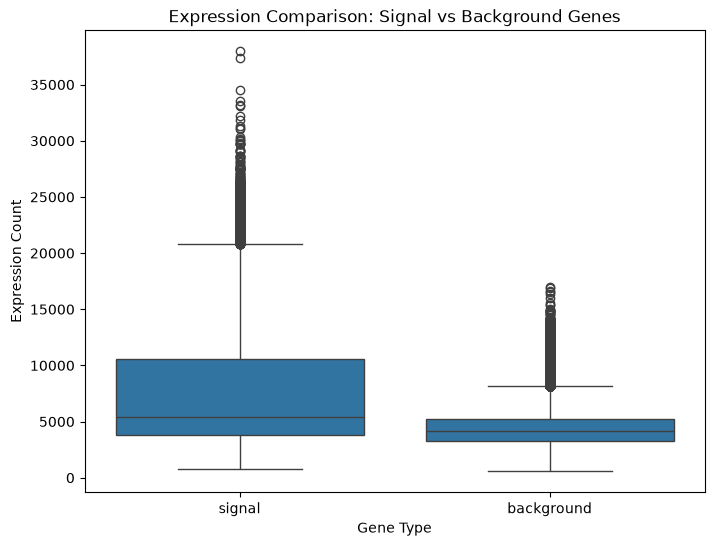

In [ ]:
# Step 11: box plot for signal vs background gene expression

plot_df = counts_df.copy()

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x="gene_type", y="expression")
plt.title("Expression Comparison: Signal vs Background Genes")
plt.xlabel("Gene Type")
plt.ylabel("Expression Count")
plt.show()

## Step 11b: validate the induced module correlation

Raw counts are contaminated by a technical correlation floor: `size_factor` multiplies every gene's mean within a cell, so ALL genes look correlated with each other regardless of module structure — normalize by `size_factor` (CPM-style) first to see the correlation the copula actually added. Restricting to Group1 cells avoids the trivial correlation induced by the group mean difference itself.

**Second floor to be aware of:** `gamma_i` (Step 6) is now additive on every gene, and since it's constant across a patient's cells, it survives the size_factor normalization above and induces its own nonzero correlation floor across ALL genes, including background. This is expected, not leakage — read the module numbers below as "distractor sits meaningfully above the shared floor (from the module copula); background sits at the floor," not "zero vs. correlated." Don't hand-copy the exact floor value anywhere permanent — it depends on `mu_background`/`sigma2`/`dispersion` together, so read it fresh from `background_corr` each time parameters change.

In [ ]:
# Step 11b: check realized within-module correlation

norm_counts_df = counts_df.merge(cells_df[["cell_id", "size_factor"]], on="cell_id")
norm_counts_df["norm_expression"] = norm_counts_df["expression"] / norm_counts_df["size_factor"]

g1_cells = cells_df.loc[cells_df["group"] == "Group1", "cell_id"]
norm_mat_g1 = norm_counts_df[norm_counts_df["cell_id"].isin(g1_cells)].pivot_table(
    index="gene_id", columns="cell_id", values="norm_expression"
)

def avg_offdiag_corr(gene_list):
    sub = norm_mat_g1.loc[gene_list]
    c = sub.T.corr().values
    mask = ~np.eye(len(gene_list), dtype=bool)
    return c[mask].mean()

module_corr_results = {}
print("Avg pairwise correlation (normalized expression, Group1 cells only)")
print("-" * 65)
for module in module_names:
    kind = "disease" if module in disease_modules else "distractor"
    genes_in_module = module_gene_lists[module]
    corr_val = avg_offdiag_corr(genes_in_module)
    module_corr_results[module] = corr_val
    print(f"{module} ({kind:10s}): {corr_val:.3f}")

bg_sample = list(np.random.choice(background_gene_ids, genes_per_module, replace=False))
background_corr = avg_offdiag_corr(bg_sample)
print(f"{'background':13s}: {background_corr:.3f}  <- shared patient-effect floor, not leakage (see note above)")

Avg pairwise correlation (normalized expression, Group1 cells only)
-----------------------------------------------------------------
M1 (disease   ): 0.594
M2 (disease   ): 0.620
M3 (disease   ): 0.586
M4 (distractor): 0.629
background   : 0.203  <- shared patient-effect floor, not leakage (see note above)


TODO: Check correlation between genes of different modules, especially signalling genes with background genes

## Step 11c: dataset overview

A one-glance summary table of every dimension and parameter used to generate this dataset.

In [ ]:
# Step 11c: dataset overview

overview = pd.DataFrame({
    "quantity": [
        "Patients (total)", "Patients per group (G1 / G2)", "Cells per patient", "Cells (total)",
        "Genes (total)", "Signal genes (in modules)", "Background genes",
        "Disease modules", "Distractor modules", "Genes per module",
        "Target within-module correlation", "Fold change (disease modules)",
        "NB dispersion", "Patient-effect variance (sigma2)"
    ],
    "value": [
        len(patients_df), f"{n_patients_group1} / {n_patients_group2}", cells_per_patient, len(cells_df),
        n_genes_total, n_signal_genes, n_genes_total - n_signal_genes,
        len(disease_modules), len(distractor_module_names), genes_per_module,
        within_module_correlation, fold_change,
        dispersion, sigma2
    ]
})
overview

,quantity,value
0,Patients (total),20
1,Patients per group (G1 / G2),10 / 10
2,Cells per patient,50
3,Cells (total),1000
4,Genes (total),1000
5,Signal genes (in modules),100
6,Background genes,900
7,Disease modules,3
8,Distractor modules,1
9,Genes per module,25


## Step 11d: technical and patient-effect distributions (QC)

Histograms of `size_factor` (should look roughly normal around `size_factor_mean`) and `gamma_i` (patient random effect) — a quick visual check that the technical/patient-level noise sources look like what Step 2 configured.

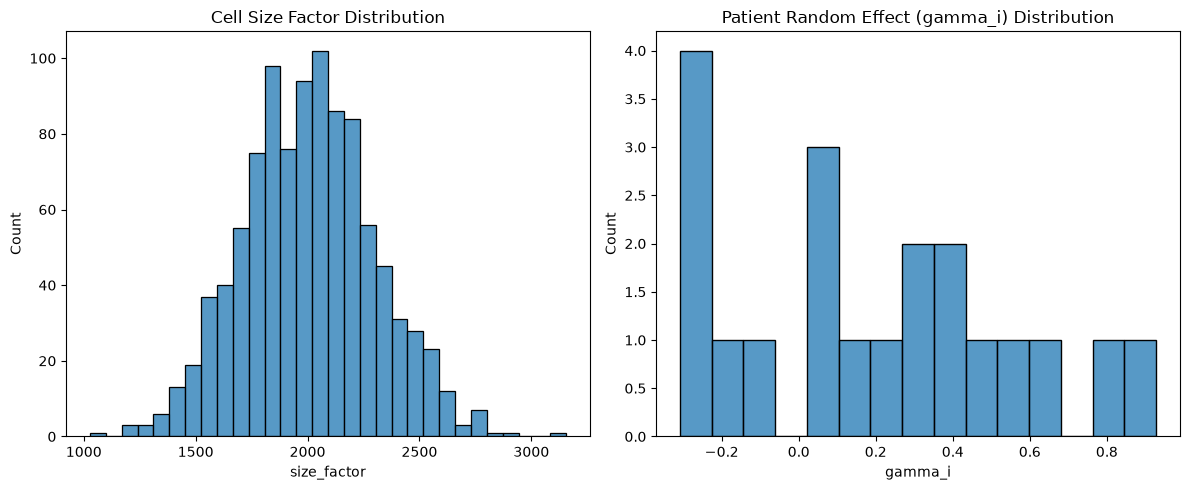

,mean,std,min,max
group,,,,
Group1,0.217930,0.301689,-0.289319,0.625811
Group2,0.170096,0.449775,-0.308214,0.928085


In [ ]:
# Step 11d: technical and patient-effect distributions (QC)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(cells_df["size_factor"], bins=30, ax=axes[0])
axes[0].set_title("Cell Size Factor Distribution")
axes[0].set_xlabel("size_factor")

sns.histplot(patients_df["gamma_i"], bins=15, ax=axes[1])
axes[1].set_title("Patient Random Effect (gamma_i) Distribution")
axes[1].set_xlabel("gamma_i")

plt.tight_layout()
plt.show()

patients_df.groupby("group")["gamma_i"].agg(["mean", "std", "min", "max"])

## Step 11e: expression distribution by gene type (log scale)

Full distributional view (not just summary stats) of signal vs. background expression, log-scaled on the x-axis since raw counts are heavily right-skewed.

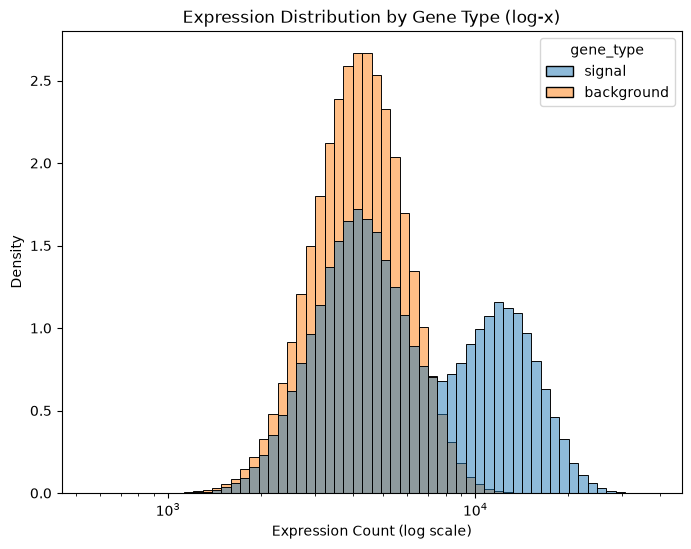

In [ ]:
# Step 11e: expression distribution by gene type (log scale)

plt.figure(figsize=(8, 6))
sns.histplot(
    data=counts_df, x="expression", hue="gene_type",
    bins=60, log_scale=(True, False), stat="density", common_norm=False, alpha=0.5
)
plt.title("Expression Distribution by Gene Type (log-x)")
plt.xlabel("Expression Count (log scale)")
plt.show()

## Step 11f: per-module expression by group

Disease modules (M1-M3 by default) should show a visible shift between Group1 and Group2; the distractor module (M4) should not, even though it's just as internally correlated. This is the per-module visual counterpart to Step 11's overall signal-vs-background box plot.

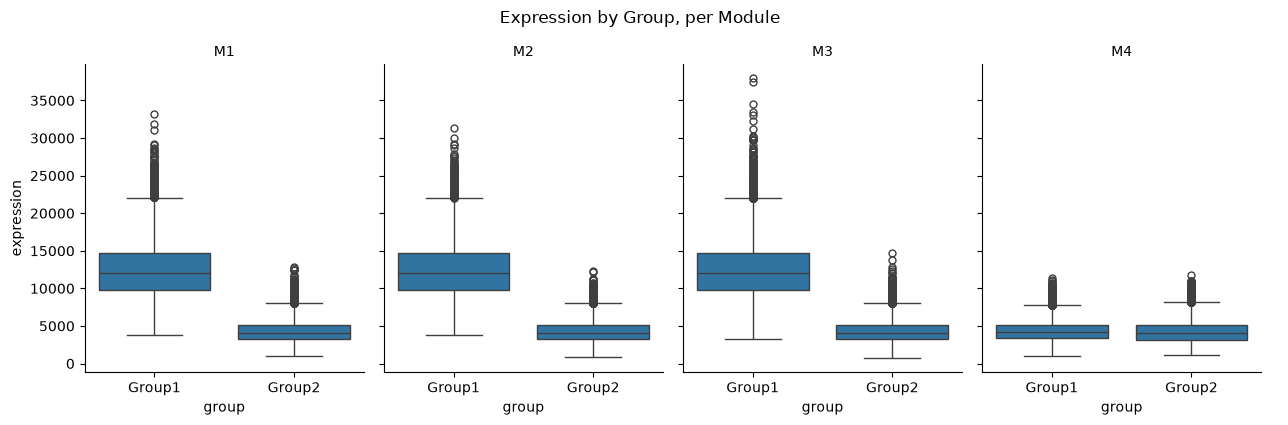

In [ ]:
# Step 11f: per-module expression by group
#
# Disease modules (M1-M3) should show a visible shift between Group1 and
# Group2; the distractor module (M4) should not, even though it is just as
# internally correlated.

module_counts = counts_df[counts_df["module_id"] != "none"]

g = sns.catplot(
    data=module_counts, x="group", y="expression", col="module_id",
    kind="box", col_order=module_names, height=4, aspect=0.8
)
g.set_titles("{col_name}")
g.fig.suptitle("Expression by Group, per Module", y=1.05)
plt.show()

## Step 11g: correlation heatmaps — disease module vs. distractor vs. background

Visual counterpart to Step 11b's numbers: a disease module and the distractor module should both show a solid block of correlation, while a random sample of background genes should look like noise. Uses the full valid correlation range (-1 to 1) with a diverging colormap centered at 0, since `correlation_noise` (Step 2) can push individual gene pairs negative.

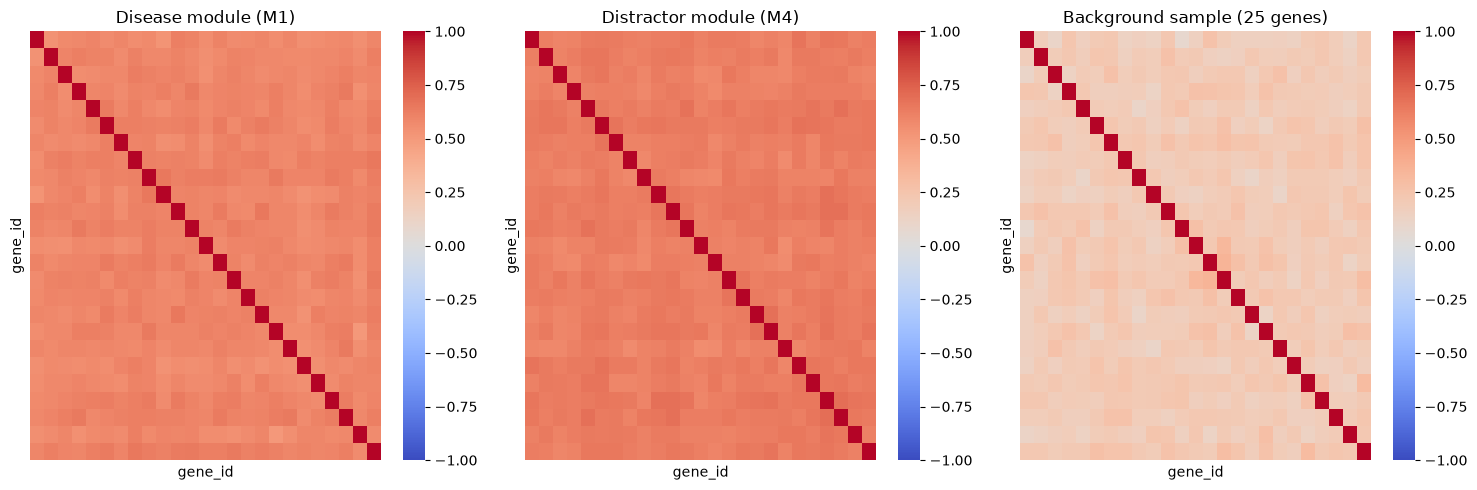

In [ ]:
# Step 11g: correlation heatmaps -- disease module vs distractor vs background

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

heatmap_specs = [
    (module_gene_lists[disease_modules[0]], f"Disease module ({disease_modules[0]})"),
    (module_gene_lists[distractor_module_names[0]], f"Distractor module ({distractor_module_names[0]})"),
    (bg_sample, "Background sample (25 genes)")
]

for ax, (gene_list, title) in zip(axes, heatmap_specs):
    corr = norm_mat_g1.loc[gene_list].T.corr()
    sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, cmap="coolwarm", center=0, cbar=True, xticklabels=False, yticklabels=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Step 11g-ii: zoomed heatmap — module 1 genes mixed with background genes

Same idea as Step 11g, but zoomed into a single 50x50 heatmap: the first 25 genes belong to disease module M1, the last 25 are a random background sample. The M1 block should visibly stand out as a bright square against the uncorrelated background genes surrounding it — a clearer illustration of "correlated module vs. noise" than the side-by-side panels above.

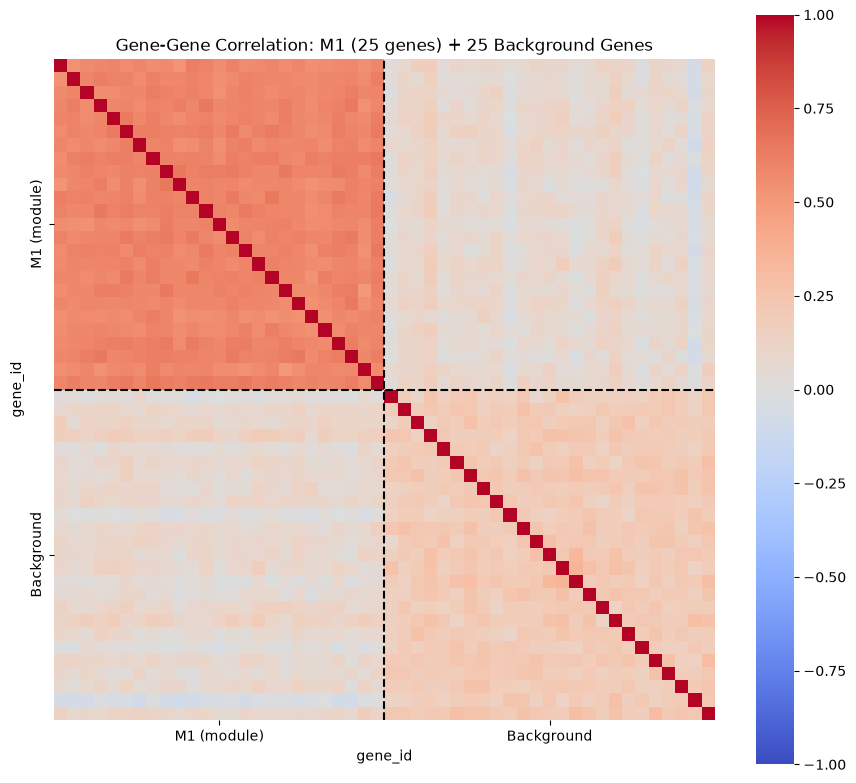

In [ ]:
# Step 11g-ii: zoomed correlation heatmap -- module 1 mixed with background genes
#
# 50 genes total: the first 25 belong to disease module M1, the last 25 are
# a random background sample (the same bg_sample used above).

module1_genes = module_gene_lists[disease_modules[0]]
mixed_gene_list = module1_genes + bg_sample
mixed_corr = norm_mat_g1.loc[mixed_gene_list].T.corr()

plt.figure(figsize=(9, 8))
ax = sns.heatmap(
    mixed_corr, vmin=-1, vmax=1, cmap="coolwarm", center=0, cbar=True,
    xticklabels=False, yticklabels=False, square=True
)
ax.axvline(len(module1_genes), color="black", linestyle="--", linewidth=1.5)
ax.axhline(len(module1_genes), color="black", linestyle="--", linewidth=1.5)
ax.set_xticks([len(module1_genes) / 2, len(module1_genes) + len(bg_sample) / 2])
ax.set_xticklabels([f"{disease_modules[0]} (module)", "Background"])
ax.set_yticks([len(module1_genes) / 2, len(module1_genes) + len(bg_sample) / 2])
ax.set_yticklabels([f"{disease_modules[0]} (module)", "Background"], rotation=90, va="center")
plt.title(f"Gene-Gene Correlation: {disease_modules[0]} (25 genes) + 25 Background Genes")
plt.tight_layout()
plt.show()

## Step 11h: PCA of cells using only module genes

If the disease modules carry real group signal, cells should visibly separate by group along the leading principal components even before any classifier is trained on them — a sanity check that the classification task is learnable at all.

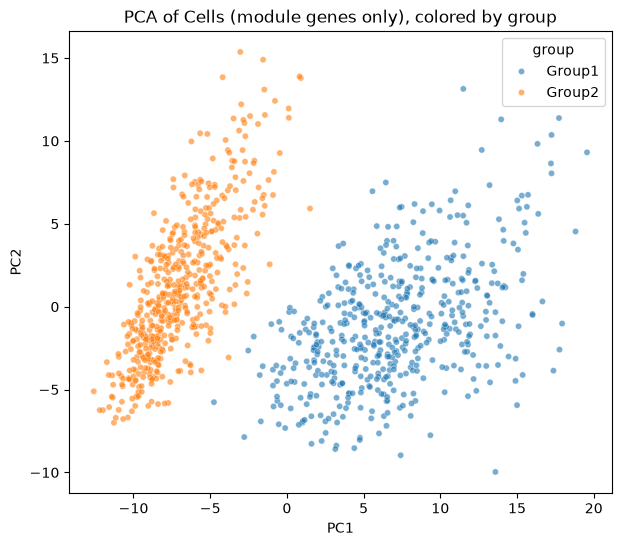

In [ ]:
# Step 11h: PCA of cells using only module genes (disease + distractor)
#
# If the disease modules carry real group signal, cells should separate by
# group along the leading principal components even before any classifier
# is trained on them.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

module_gene_ids = [g for genes in module_gene_lists.values() for g in genes]
signal_matrix = counts_df[counts_df["gene_id"].isin(module_gene_ids)].pivot_table(
    index="cell_id", columns="gene_id", values="expression", fill_value=0
)

cell_group_lookup = cells_df.set_index("cell_id")["group"].loc[signal_matrix.index]

scaled = StandardScaler().fit_transform(signal_matrix.values)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaled)

pca_df = pd.DataFrame({"PC1": pcs[:, 0], "PC2": pcs[:, 1], "group": cell_group_lookup.values})

plt.figure(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="group", alpha=0.6, s=20)
plt.title("PCA of Cells (module genes only), colored by group")
plt.show()

TODO: Next step, run the plain stochastic gating on datasets with correlation and the one without the correlation and compare performance

TODO: next after that, modify their stochastic gating to consider correlation of features in the stochastic gating model itself

---
**Data generation complete.** `counts_df`, `genes_df` (with `module_id`/`is_disease_module`), `patients_df`, and `cells_df` are ready to be picked up by a baseline-methods notebook (`%run` this notebook first, or copy the relevant setup cells).